# 📅 Pandas Part 7: Time Series Analysis Masterclass
**From Strings to Timestamps, Date Ranges, and Time-Based Analytics**

Welcome to Part 7! Time is the most critical dimension in data science. In this notebook, we will master how Pandas handles dates and times, combining the ease of Python's `datetime` with the blazing speed of NumPy's `datetime64`.

Every concept follows our **Mastery Framework**:
`Theory → Mental Model → Diagram → Code → Mistake → Practice Ladder → Debug → Interview → Real World`
```


In [2]:
# ==========================================
# 🛠️ SETUP & INDUSTRY MOCK DATA
# ==========================================
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

print(f"Pandas Version: {pd.__version__}")
print("✅ Environment Ready!")

# Mock Expense Data (Simulating the CSV from your session)
np.random.seed(42)
dates_str = ['3/2/2022 10:11', '3/2/2022 14:30', '3/1/2022 19:50', 
             '3/1/2022', '2/28/2022 11:56', '2/28/2022 11:45', 
             '1/31/2022 08:44', '1/31/2022 08:27', '2023/130/1'] # Notice the dirty data!
categories = ['Food', 'Other', 'Food', 'Transportation', 'Food', 'Other', 'Transportation', 'Other', 'Food']
amounts = [50.0, 300.0, 78.0, 30.0, 339.15, 200.0, 50.0, 200.0, 100.0]
types = ['Expense', 'Expense', 'Expense', 'Expense', 'Expense', 'Income', 'Expense', 'Expense', 'Expense']

expense_df = pd.DataFrame({
    'Date': dates_str,
    'Category': categories,
    'INR': amounts,
    'Income/Expense': types
})
print("📊 Mock Expense Data Loaded!")


Pandas Version: 3.0.3
✅ Environment Ready!
📊 Mock Expense Data Loaded!


# 📘 Module 1: Timestamp & DatetimeIndex Fundamentals

## 🧠 1. Theory
Python has a built-in `datetime` module, but it's slow for large datasets. NumPy introduced `datetime64` for vectorized speed. **Pandas `Timestamp`** bridges the gap: it offers the user-friendly syntax of Python `datetime` with the vectorized power of NumPy.

## 💡 2. Mental Model
- **`Timestamp`**: A single pin on a calendar.
- **`DatetimeIndex`**: A fully printed calendar timeline used to index your data.

## 📊 3. Visual Diagram
```text
Python datetime  --->  Slow, object-oriented, hard to vectorize
NumPy datetime64 --->  Fast, C-level, hard to read/write manually
Pandas Timestamp --->  BEST OF BOTH: Easy syntax + Vectorized speed
```

## 💻 4. Code Example
```python
# 1. Creating a Timestamp
ts = pd.Timestamp('2023-01-05 09:21:56')

# 2. Fetching Attributes
print(ts.year, ts.month, ts.day, ts.hour)

# 3. Creating a DatetimeIndex
dt_idx = pd.DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03'])
```

## ⚠️ 5. Common Mistake
Passing an unparseable string format without telling Pandas how to read it.
```python
pd.Timestamp('2023/1/5/9/21') # ❌ ParserError!
```

## 🎯 6. Practice Ladder (Tasks to Perform)
*   **Level 1 (Easy):** Create a `Timestamp` for your birthday using a string (e.g., `'1995-08-15'`).
*   **Level 2 (Medium):** Create a `Timestamp` using Python's native `datetime.datetime` object.
*   **Level 3 (Hard):** Create a `DatetimeIndex` from a list of 3 `pd.Timestamp` objects.
*   **Level 4 (Expert):** Create a Pandas Series with random sales data, using your `DatetimeIndex` as the index.



## 🐛 7. Debugging Challenge
**Why does this fail?**
```python
pd.Timestamp('5th January 2023 9:21AM') # Works
pd.Timestamp('2023/1/5/9/21')           # Fails
```
*How do you fix the second one to represent Jan 5, 2023, at 9:21?*

## 🎤 8. Interview Question
**Q:** Why does Pandas use `Timestamp` instead of just Python's native `datetime`?
**A:** Python's `datetime` is an object type. If you have an array of 1 million datetimes, Pandas stores them as an array of pointers to Python objects (slow). `Timestamp` maps to NumPy's `datetime64[ns]`, allowing contiguous memory storage and blazing-fast vectorized operations.

## 🌍 9. Real World Scenario
**High-Frequency Trading:** Storing millions of stock ticks per second requires `datetime64[ns]` precision and the memory efficiency that only Pandas/NumPy can provide.


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 1)
# ==========================================
# Task 1
bday = pd.Timestamp('1995-08-15')
print(bday)

# Task 2
ts_native = pd.Timestamp(dt.datetime(2023, 1, 5, 9, 21, 56))
print(ts_native)

# Task 3
dt_idx = pd.DatetimeIndex([
    pd.Timestamp('2023-01-01'), 
    pd.Timestamp('2023-01-02'), 
    pd.Timestamp('2023-01-03')
])
print(dt_idx)

# Task 4
sales_series = pd.Series([100, 150, 200], index=dt_idx)
print(sales_series)

# Debugging Fix:
# The slashes and colons were mixed up. Use standard ISO format or spaces.
fixed_ts = pd.Timestamp('2023-01-05 09:21:00')
print(fixed_ts)

```

</details>

In [3]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 1
# ==========================================
# Example Execution
ts = pd.Timestamp('2023-01-05 09:21:56')
print(f"Year: {ts.year}, Month: {ts.month}")

# --- YOUR TURN ---
# Task 1: Create Timestamp for birthday
# Task 2: Create Timestamp from dt.datetime
# Task 3: Create DatetimeIndex from Timestamps
# Task 4: Create Series with DatetimeIndex


Year: 2023, Month: 1


# 📘 Module 2: Generating Date Ranges (`date_range`)

## 🧠 1. Theory
Often, you need to generate a continuous timeline (e.g., every day for a year, or every month-end). `pd.date_range()` is the engine for this.

## 💡 2. Mental Model
A **Metronome**: You set the `start`, the `end` (or number of `periods`), and the `freq` (tick speed).

## 💻 4. Code Example & Frequency Aliases
```python
# Daily
pd.date_range('2023-01-01', '2023-01-05', freq='D')

# Business Days (Skips Weekends!)
pd.date_range('2023-01-01', periods=5, freq='B')

# Month End vs Month Start
pd.date_range('2023-01-01', periods=3, freq='M')  # 'ME' in newer Pandas
pd.date_range('2023-01-01', periods=3, freq='MS')

# Year End
pd.date_range('2023-01-01', periods=3, freq='A')  # 'YE' in newer Pandas
```

## ⚠️ 5. Common Mistake
Confusing `M` (Month End) with `MS` (Month Start).
```python
pd.date_range('2023-01-15', periods=2, freq='M')  # Returns Jan 31, Feb 28
pd.date_range('2023-01-15', periods=2, freq='MS') # Returns Feb 01, Mar 01
```

## 🎯 6. Practice Ladder (Tasks to Perform)
*   **Level 1 (Easy):** Generate dates for the first 10 days of 2023.
*   **Level 2 (Medium):** Generate the last day of every month for the year 2024 (a leap year!).
*   **Level 3 (Hard):** Generate hourly timestamps for a single 24-hour day.
*   **Level 4 (Expert):** Generate exactly 50 business days starting from today.

## 🐛 7. Debugging Challenge
**Why does this output look weird?**
```python
pd.date_range('2023-01-01', '2023-01-10', freq='W-THU')
```
*What does `W-THU` mean, and how do you change it to anchor on Sundays?*

## 🎤 8. Interview Question
**Q:** What is the difference between `freq='B'` and `freq='C'`?
**A:** `'B'` is standard Business Days (Mon-Fri). `'C'` is **Custom Business Days**, which allows you to pass a list of specific holidays to exclude (e.g., excluding Diwali or Christmas).

## 🌍 9. Real World Scenario
**Financial Modeling:** Generating a timeline of trading days (`freq='B'`) to align daily stock closing prices, automatically ignoring weekends when the market is closed.


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 2)
# ==========================================
# Task 1
print(pd.date_range('2023-01-01', periods=10, freq='D'))

# Task 2 (Note: 'M' is deprecated in Pandas 2.2+, use 'ME' if warned)
print(pd.date_range('2024-01-01', '2024-12-31', freq='ME')) 

# Task 3
print(pd.date_range('2023-01-01', periods=24, freq='H'))

# Task 4
print(pd.date_range(start=pd.Timestamp.today(), periods=50, freq='B'))

# Debugging Fix:
# W-THU means "Weekly, anchored on Thursday". 
# To anchor on Sunday, use 'W-SUN' or just 'W'.
print(pd.date_range('2023-01-01', '2023-01-31', freq='W-SUN'))
```

</details>


In [4]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 2
# ==========================================
# Example Execution
print("Business Days:\n", pd.date_range('2023-01-01', periods=5, freq='B'))

# --- YOUR TURN ---
# Task 1: First 10 days of 2023
# Task 2: Month ends for 2024
# Task 3: Hourly for 1 day
# Task 4: 50 business days from today


Business Days:
 DatetimeIndex(['2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05',
               '2023-01-06'],
              dtype='datetime64[us]', freq='B')


# 📘 Module 3: Converting & Cleaning Dates (`to_datetime`)

## 🧠 1. Theory
Real-world data is messy. Dates come as strings (`'2023/01/01'`), integers (`20230101`), or weird formats. `pd.to_datetime()` is your universal translator.

## 💡 2. Mental Model
A **Customs Officer**: It inspects incoming string data and stamps it with the official `datetime64` visa so it can enter the Pandas ecosystem.

## 💻 4. Code Example & The Magic of `coerce`
```python
# Standard conversion
s = pd.Series(['2023-01-01', '2023-01-02'])
pd.to_datetime(s)

# Handling Dirty Data (The most important parameter!)
dirty = pd.Series(['2023-01-01', 'NOT A DATE', '2023-13-45'])
pd.to_datetime(dirty, errors='coerce') # Turns bad data into NaT (Not a Time)
```

## ⚠️ 5. Common Mistake
Letting Pandas guess the format on millions of rows, which is incredibly slow.
```python
# ❌ Slow on large datasets
pd.to_datetime(huge_series) 

# ✅ Blazing Fast
pd.to_datetime(huge_series, format='%Y-%m-%d')
```

## 🎯 6. Practice Ladder (Tasks to Perform)
*   **Level 1 (Easy):** Convert the `Date` column in `expense_df` to datetime.
*   **Level 2 (Medium):** Convert a Series containing `['2023/01/01', 'Invalid', '2023/02/30']` using `errors='coerce'`.
*   **Level 3 (Hard):** Drop all rows where the date conversion failed (resulted in `NaT`).
*   **Level 4 (Expert):** Parse a column of integers like `[20230101, 20230102]` into datetimes.


## 🐛 7. Debugging Challenge
**Why does this throw an error?**
```python
s = pd.Series(['01-02-2023', '02-03-2023'])
pd.to_datetime(s) # Returns Jan 2nd or Feb 3rd? It's ambiguous!
```
*How do you force Pandas to read this as Day-Month-Year?*

## 🎤 8. Interview Question
**Q:** What is the difference between `errors='coerce'`, `errors='ignore'`, and `errors='raise'`?
**A:** 
- `'raise'` (Default): Stops execution and throws an error.
- `'coerce'`: Replaces invalid parsing with `NaT` (Null).
- `'ignore'`: Returns the original input string unchanged if parsing fails.

## 🌍 9. Real World Scenario
**Data Ingestion Pipeline:** When reading a 10GB CSV of server logs, some timestamps are corrupted. Using `errors='coerce'` allows the pipeline to continue, flagging bad rows as `NaT` for later investigation rather than crashing the entire ETL job.


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 3)
# ==========================================
# Task 1
expense_df['Date'] = pd.to_datetime(expense_df['Date'], errors='coerce')
print(expense_df.dtypes)

# Task 2
s_dirty = pd.Series(['2023/01/01', 'Invalid', '2023/02/30'])
print(pd.to_datetime(s_dirty, errors='coerce'))

# Task 3
clean_expense = expense_df.dropna(subset=['Date'])
print(f"Rows before: {len(expense_df)}, Rows after: {len(clean_expense)}")

# Task 4
int_dates = pd.Series([20230101, 20230102, 20230103])
print(pd.to_datetime(int_dates, format='%Y%m%d'))

# Debugging Fix:
# Use the dayfirst parameter!
s_amb = pd.Series(['01-02-2023', '02-03-2023'])
print(pd.to_datetime(s_amb, dayfirst=True))
```

</details>

In [ ]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 3
# ==========================================
# Example Execution
dirty = pd.Series(['2023-01-01', 'NOT A DATE', '2023/130/1'])
print("Coerced:\n", pd.to_datetime(dirty, errors='coerce'))

# --- YOUR TURN ---
# Task 1: Convert expense_df['Date']
# Task 2: Coerce invalid dates
# Task 3: Drop NaT rows
# Task 4: Parse integers to datetime


# 📘 Module 4: The `.dt` Accessor & Time Analytics

## 🧠 1. Theory
Once your data is a `datetime64` object, you can extract specific components (Year, Month, Day of Week) or ask boolean questions (Is it a weekend? Is it the end of the month?). We use the `.dt` accessor for this.

## 💡 2. Mental Model
A **Swiss Army Knife** attached to your datetime column. You can pull out the blade you need (`.dt.year`, `.dt.day_name()`, `.dt.is_month_end`).

## 💻 4. Code Example
```python
# Extracting components
df['Year'] = df['Date'].dt.year
df['Day_Name'] = df['Date'].dt.day_name()

# Boolean masking
is_month_end = df[df['Date'].dt.is_month_end]

# Grouping by time features
df.groupby(df['Date'].dt.month_name())['INR'].sum()
```

## ⚠️ 5. Common Mistake
Trying to use `.dt` on a standard object/string column, or using it on a DataFrame instead of a Series.
```python
df['String_Date'].dt.year # ❌ AttributeError: Can only use .dt accessor with datetimelike values
df.dt.year                # ❌ AttributeError: DataFrame has no attribute dt
```

## 🎯 6. Practice Ladder (Tasks to Perform)
*   **Level 1 (Easy):** Extract the `month_name()` from the cleaned `expense_df['Date']`.
*   **Level 2 (Medium):** Create a boolean mask to filter only **Weekend** expenses (Saturday/Sunday).
*   **Level 3 (Hard):** Group the expenses by `day_name()` and calculate the average `INR` spent.
*   **Level 4 (Expert):** Filter the dataset to show only transactions that occurred on the **last day of the month** (`is_month_end`).


## 🐛 7. Debugging Challenge
**Why does this fail?**
```python
df['Date'].dt.day_name().value_counts().plot(kind='bar')
```
*Hint: Look at the order of the X-axis. How do you make the bars appear in chronological order (Monday to Sunday)?*

## 🎤 8. Interview Question
**Q:** How do you calculate the time difference between two datetime columns?
**A:** You simply subtract them! `df['End_Time'] - df['Start_Time']`. This returns a `Timedelta` object, from which you can extract `.dt.days` or `.dt.seconds`.

## 🌍 9. Real World Scenario
**Retail Analytics:** Extracting `day_name()` and `hour` from transaction timestamps to build a heatmap showing peak shopping hours (e.g., "Fridays at 6 PM"), allowing the business to optimize staff scheduling.


<details>
<summary>Click for solution</summary>

```
# ==========================================
# ✅ SOLUTIONS (Module 4)
# ==========================================
# Task 1
clean_df['Month_Name'] = clean_df['Date'].dt.month_name()
print(clean_df['Month_Name'].value_counts())

# Task 2
weekends = clean_df[clean_df['Date'].dt.day_name().isin(['Saturday', 'Sunday'])]
print(f"Weekend transactions: {len(weekends)}")

# Task 3
day_avg = clean_df.groupby('Day_Name')['INR'].mean()
print(day_avg)

# Task 4
month_end = clean_df[clean_df['Date'].dt.is_month_end]
print("Month End Transactions:\n", month_end)

# Debugging Fix:
# To order the bar chart chronologically, we must convert the index to a Categorical type!
day_counts = clean_df['Date'].dt.day_name().value_counts()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts.index = pd.CategoricalIndex(day_counts.index, categories=days_order, ordered=True)
day_counts.sort_index().plot(kind='bar', title='Transactions by Day of Week')
plt.show()
```

</details>


In [5]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 4
# ==========================================
# Ensure Date is datetime
expense_df['Date'] = pd.to_datetime(expense_df['Date'], errors='coerce')
clean_df = expense_df.dropna(subset=['Date'])

# Example Execution
clean_df['Day_Name'] = clean_df['Date'].dt.day_name()
print(clean_df[['Date', 'Day_Name']].head())

# --- YOUR TURN ---
# Task 1: Extract month_name
# Task 2: Filter Weekends
# Task 3: Groupby day_name and mean
# Task 4: Filter is_month_end


                 Date   Day_Name
0 2022-03-02 10:11:00  Wednesday
1 2022-03-02 14:30:00  Wednesday
2 2022-03-01 19:50:00    Tuesday
4 2022-02-28 11:56:00     Monday
5 2022-02-28 11:45:00     Monday


# 🏢 Mini Project: End-to-End Time Series Pipeline

## 🚀 Capstone Challenge: The Expense Analyzer
You are building an automated financial dashboard. You must take the raw, messy `expense_df`, clean it, extract time features, and generate business insights.

**Requirements:**
1. **Clean:** Convert `Date` to datetime, coercing errors. Drop invalid rows.
2. **Feature Engineer:** Extract `Month`, `Day_Name`, and `Is_Weekend` (boolean).
3. **Analyze:** Create a Pivot Table showing total `INR` spent (filter only 'Expense') by `Month` (rows) and `Category` (columns).
4. **Visualize:** Plot a line chart of total daily expenses over time.


--- Executive Pivot Table ---
Category    Food  Other  Transportation
Month                                  
January     0.00  200.0            50.0
February  339.15    0.0             0.0
March     128.00  300.0             0.0


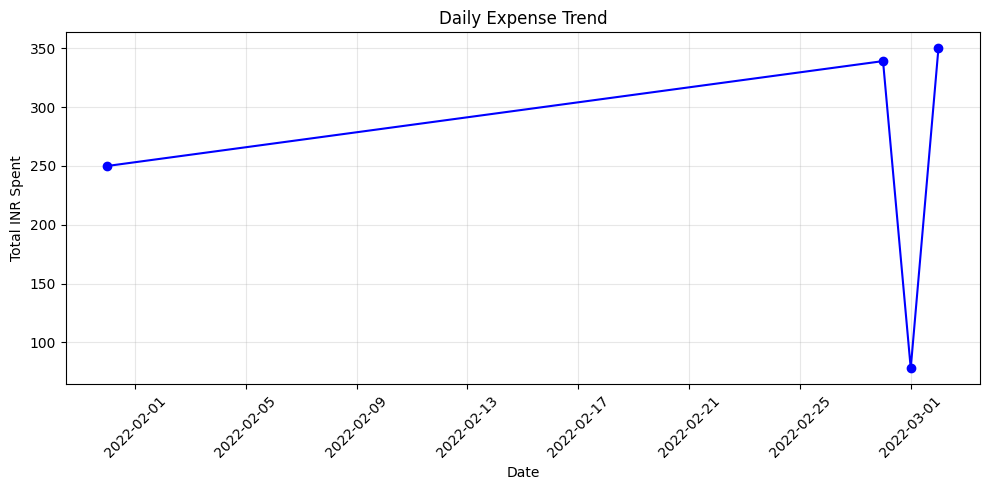


🎉 Pipeline Complete! You are now a Time Series Ninja.


In [6]:
# ==========================================
# 🏢 MINI PROJECT SOLUTION
# ==========================================
# 1. Clean
df = expense_df.copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

# 2. Feature Engineer
df['Month'] = df['Date'].dt.month_name()
df['Day_Name'] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Date'].dt.day_name().isin(['Saturday', 'Sunday'])

# Filter only expenses for analysis
expenses = df[df['Income/Expense'] == 'Expense'].copy()

# 3. Analyze (Pivot Table)
# Note: We use a specific month order for better readability
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

pivot = expenses.pivot_table(
    index='Month', 
    columns='Category', 
    values='INR', 
    aggfunc='sum', 
    fill_value=0
)
# Reindex to chronological month order (only keeping months present in data)
present_months = [m for m in month_order if m in pivot.index]
pivot = pivot.reindex(present_months)

print("--- Executive Pivot Table ---")
print(pivot)

# 4. Visualize (Daily Trend)
daily_expenses = expenses.groupby(expenses['Date'].dt.date)['INR'].sum()
daily_expenses.index = pd.to_datetime(daily_expenses.index)

plt.figure(figsize=(10, 5))
plt.plot(daily_expenses.index, daily_expenses.values, marker='o', linestyle='-', color='b')
plt.title('Daily Expense Trend')
plt.xlabel('Date')
plt.ylabel('Total INR Spent')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🎉 Pipeline Complete! You are now a Time Series Ninja.")


# 🎉 Congratulations!
You have mastered **Pandas Part 7: Time Series Analysis**.
You now know how to:
✅ Understand the difference between Python datetime, NumPy datetime64, and Pandas Timestamp.
✅ Generate complex timelines using `pd.date_range` and frequency aliases.
✅ Clean messy, real-world string dates using `pd.to_datetime` and `errors='coerce'`.
✅ Extract powerful features using the `.dt` accessor for grouping and filtering.
✅ Build end-to-end time-based analytical pipelines.

### 🚀 Next Steps
You are now ready for **Pandas Part 8: Advanced Time Series** – Time-based indexing, Resampling (`resample`), Rolling Windows (`rolling`), and Timezone handling!
```